## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar


### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.


In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')


In [ ]:
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [ ]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


In [ ]:
traffic.isna().sum()

Country                           0
City                              0
UpdateTimeUTC                     0
JamsDelay                         0
TrafficIndexLive                  0
JamsLengthInKms                   0
JamsCount                         0
TrafficIndexWeekAgo               0
UpdateTimeUTCWeekAgo              0
TravelTimeLivePer10KmsMins        0
TravelTimeHistoricPer10KmsMins    0
MinsDelay                         0
dtype: int64

In [ ]:
eco.isna().sum()

Year               0
City               0
Country            0
City GDP/capita    0
Unemployment %     0
PM2.5 (μg/m³)      0
Population (M)     0
dtype: int64

In [ ]:
traffic.duplicated().sum()

0

In [ ]:
eco.duplicated().sum()

0


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos



**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.




In [ ]:
traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232



En la estructura del DF traffic, se observa que:

- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` tienen tipo `object` pero representan fechas, por lo que deberán convertirse a tipo `datetime`.
- Las demás variables numéricas tienen formatos adecuados (`float64`).
- No se encontraron valores nulos.
- No se encontraron registros duplicados.

In [ ]:
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"



En la estructura del DF eco, se observa que:

- Las columnas `City GDP/capita`, `Unemployment %`, `PM2.5 (µg/m³)` y `Population (M)` tienen tipo `object` y requieren conversión a formato numérico.
- Los valores utilizan comas como separadores decimales y algunos contienen símbolos como `%`.
- No se encontraron valores nulos.
- No se encontraron registros duplicados.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.




In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns = (
    traffic.columns
    .str.replace('([a-z])([A-Z])', r'\1_\2', regex=True)
    .str.lower()
)
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utcweek_ago',
       'travel_time_live_per10kms_mins', 'travel_time_historic_per10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco.columns = (
    eco.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('%', 'pct')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('.', '')
)
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_μg_m³', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.



<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(
    traffic['update_time_utc']
)

traffic['update_time_utcweek_ago'] = pd.to_datetime(
    traffic['update_time_utcweek_ago']
)

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   country                             1004464 non-null  object        
 1   city                                1004464 non-null  object        
 2   update_time_utc                     1004464 non-null  datetime64[ns]
 3   jams_delay                          1004464 non-null  float64       
 4   traffic_index_live                  1004464 non-null  float64       
 5   jams_length_in_kms                  1004464 non-null  float64       
 6   jams_count                          1004464 non-null  float64       
 7   traffic_index_week_ago              1004464 non-null  float64       
 8   update_time_utcweek_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per10kms_mins      1004464 non-null  float64       

In [ ]:

# Limpia separadores y convierte columnas numéricas en eco

eco['city_gdp_capita'] = (
    eco['city_gdp_capita']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['unemployment_pct'] = (
    eco['unemployment_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['population_m'] = (
    eco['population_m']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)



eco['population'] = eco['population_m'] * 1000000.

# verificar el cambio
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25_μg_m³        30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25_μg_m³,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.


**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.


In [ ]:

traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utcweek_ago,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024

traffic_2024 = traffic[traffic['year'] == 2024].copy()

eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utcweek_ago,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25_μg_m³,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad


**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.




<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'], as_index=False)
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_in_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per10kms_mins': 'mean',
        'travel_time_historic_per10kms_mins': 'mean'
    })
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:

traffic_city_year_2024.sort_values(
    'jams_delay',
    ascending=False
).head(1)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.21819,389.239265,594.969392,1.855542,21.809092,19.95355


La ciudad con el mayor tiempo promedio de tráfico es ... Mexico City


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.



In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live',
             'jams_length_in_kms', 'jams_count', 'mins_delay',
             'travel_time_live_per10kms_mins', 'travel_time_historic_per10kms_mins']






right_cols = [
    'city',
    'year',
    'city_gdp_capita',
    'unemployment_pct',
    'pm25_μg_m³',
    'population'
]


# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()

eco_2024_small = eco_2024[right_cols].copy()

merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city', 'year'],
    how='inner'
)

merged.head()



,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per10kms_mins,travel_time_historic_per10kms_mins,city_gdp_capita,unemployment_pct,pm25_μg_m³,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

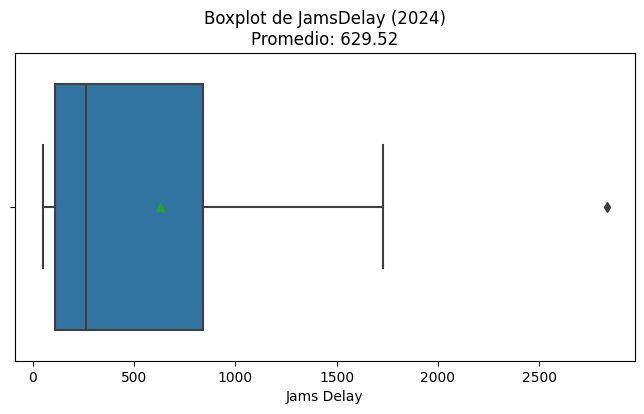

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=merged['jams_delay'],
    showmeans=True
)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()

plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('Jams Delay')

plt.show()


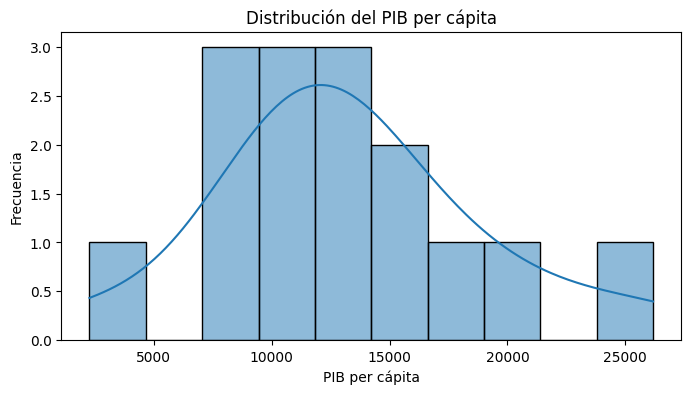

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

plt.figure(figsize=(8, 4))

sns.histplot(
    merged['city_gdp_capita'],
    bins=10,
    kde=True
)

plt.title('Distribución del PIB per cápita')
plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia')

plt.show()

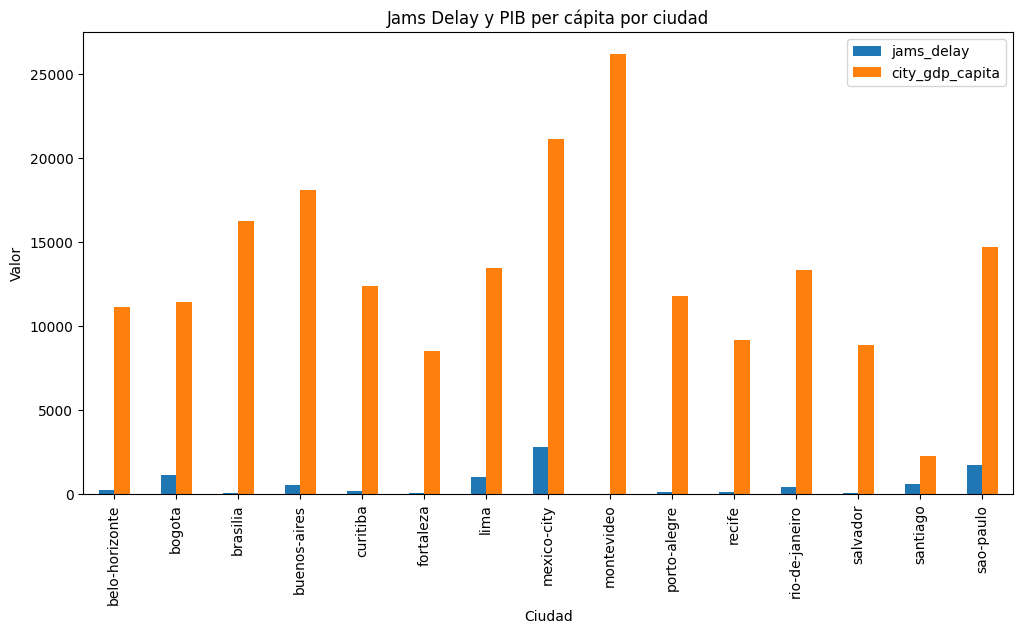

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(
    x='city',
    y=['jams_delay', 'city_gdp_capita'],
    kind='bar',
    figsize=(12, 6)
)

plt.title('Jams Delay y PIB per cápita por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Valor')

plt.xticks(rotation=90)

plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

Al analizar los gráficos, no se observa una relación completamente clara entre el PIB per cápita y los niveles de congestión. Algunas ciudades con un PIB per cápita elevado también presentan altos niveles de tráfico, mientras que otras mantienen niveles de congestión moderados.

Los datos sugieren que la congestión vehicular no depende únicamente del desempeño económico de una ciudad. Factores como la densidad poblacional, la infraestructura de transporte, la planificación urbana y la cantidad de vehículos en circulación también pueden influir significativamente.

Además, se identifican diferencias importantes entre ciudades, lo que indica que el crecimiento económico no necesariamente implica mayores problemas de movilidad. Por ello, sería recomendable complementar el análisis con variables adicionales para comprender mejor la relación entre economía y tráfico.

In [ ]:
# Exporta el dataset final como CSV
merged.to_csv(
    'iadb_mobility_economy_2024_clean.csv',
    index=False
)


---

# 🧾 Resumen ejecutivo (plantilla)


**Contexto & objetivo:**  

El objetivo de este análisis fue estudiar la relación entre la movilidad urbana y la productividad económica en distintas ciudades de América Latina durante 2024. Para ello, se integraron datos de tráfico urbano provenientes de TomTom con indicadores económicos de la OCDE, incluyendo PIB per cápita, desempleo, contaminación y población


**Cobertura de datos:**  
-El análisis se enfocó en el año 2024 y utilizó información agregada a nivel ciudad. Se combinaron indicadores de congestión vehicular, retrasos de viaje y tiempos promedio de traslado con variables económicas y demográficas. La integración permitió construir una base consolidada para comparar desempeño económico y movilidad urbana.

**Metodología (alto nivel):**  
Se realizó un proceso de limpieza y transformación de datos que incluyó la conversión de fechas, corrección de formatos numéricos, estandarización de nombres de columnas y creación de variables derivadas. Posteriormente, los datos de tráfico fueron agregados por ciudad y año, y se utilizó una unión tipo INNER JOIN para integrar la información económica y de movilidad. Finalmente, se generaron visualizaciones para analizar distribuciones y posibles relaciones entre las variables.

**Hallazgos iniciales:**  

Los resultados muestran que no existe una relación directa y uniforme entre el PIB per cápita y los niveles de congestión vehicular. Algunas ciudades con altos niveles de ingreso presentan también altos niveles de tráfico, mientras que otras mantienen niveles moderados de congestión. Se identificó a Ciudad de México como una de las ciudades con mayores niveles promedio de retraso por congestión, evidenciando la importancia de considerar factores adicionales como infraestructura urbana, densidad poblacional y planeación del transporte.

**Recomendaciones**  
Se recomienda profundizar el análisis incorporando variables relacionadas con infraestructura de transporte público, crecimiento urbano y distribución poblacional. Asimismo, ciudades con altos niveles de congestión y desempeño económico moderado podrían ser candidatas prioritarias para futuras inversiones en movilidad urbana, ya que la mejora de la infraestructura de transporte puede contribuir a incrementar la productividad y la calidad de vida de la población.

-Con base en el análisis exploratorio realizado, no se identificó una correlación fuerte y directa entre el PIB per cápita y la congestión vehicular. Sin embargo, ciudades como Bogotá y Ciudad de México muestran niveles elevados de congestión que justifican un análisis más profundo para evaluar posibles inversiones en infraestructura de transporte. Se recomienda complementar este estudio con indicadores adicionales antes de priorizar una ciudad específica para inversión